In [1]:
try:
    import tensorflow as tf
except:
    !pip install tensorflow
    import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [5]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9521 - loss: 0.1596 - val_accuracy: 0.9778 - val_loss: 0.0787
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9831 - loss: 0.0544 - val_accuracy: 0.9840 - val_loss: 0.0548
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9886 - loss: 0.0339 - val_accuracy: 0.9826 - val_loss: 0.0649
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9927 - loss: 0.0225 - val_accuracy: 0.9849 - val_loss: 0.0554
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9951 - loss: 0.0155 - val_accuracy: 0.9864 - val_loss: 0.0529


In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0465
Test Accuracy: 0.9864000082015991


In [9]:
sample = x_test[0].reshape(1,28,28,1)
prediction = model.predict(sample)

print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Predicted Digit: 7
Actual Digit: 7


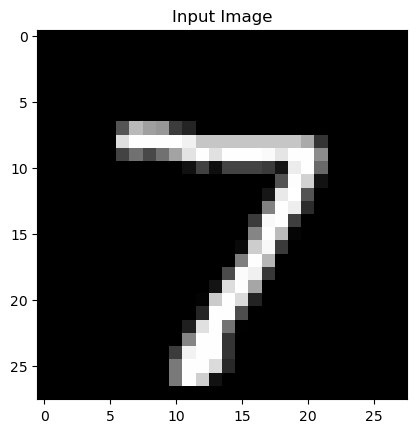

In [10]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Input Image")
plt.show()

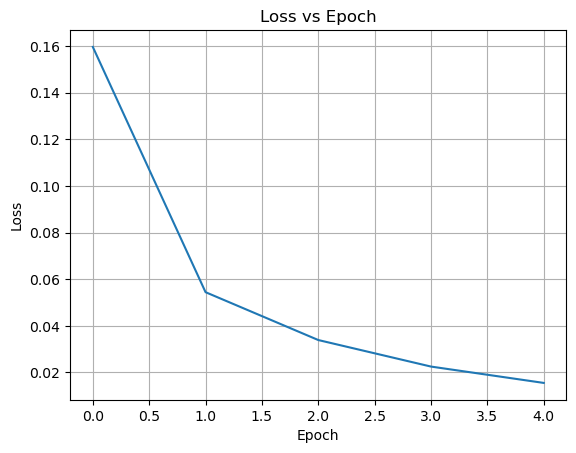

In [11]:
plt.plot(history.history['loss'])
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

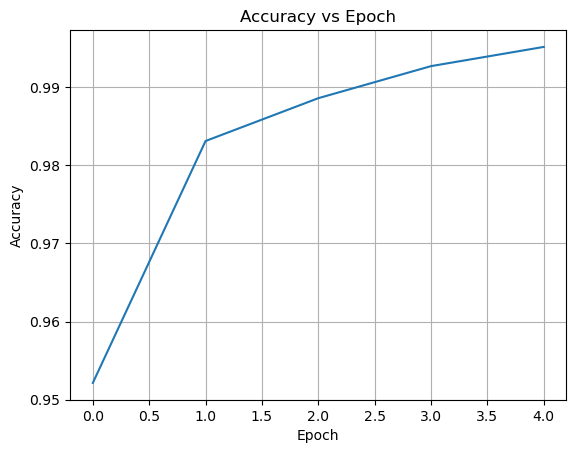

In [12]:
plt.plot(history.history['accuracy'])
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()